# Import libraries

In [1]:
!pip3 install split-folders
!pip3 install tqdm
!pip3 install scikit-image
!pip3 install opencv-python
!pip3 install scikit-learn
!pip3 install tensorflow

In [2]:
import os, shutil
import splitfolders
import random
import numpy as np
import pandas as pd
import itertools
from tqdm import tqdm, tqdm_notebook
import cv2
from scipy import stats
from sklearn.metrics import confusion_matrix, roc_curve,auc, classification_report, precision_score, recall_score
from sklearn.linear_model import LinearRegression

import skimage
import skimage.segmentation
import copy

# Data Visualization
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('ggplot')
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg


import tensorflow as tf
print(tf.__version__)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Input, Flatten, Dense, MaxPooling2D, Conv2D, Dropout
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.optimizers import SGD, RMSprop, Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications.imagenet_utils import decode_predictions

2.21.0


In [ ]:
from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D
from tensorflow.keras.layers import Dense, Reshape, Multiply, Add, Conv2D, Activation, Concatenate

def cbam_block(feature_map, ratio=8):
    # Channel Attention
    avg_pool = GlobalAveragePooling2D()(feature_map)
    max_pool = GlobalMaxPooling2D()(feature_map)

    shared_dense1 = Dense(feature_map.shape[-1] // ratio, activation='relu')
    shared_dense2 = Dense(feature_map.shape[-1], activation='sigmoid')

    avg_out = shared_dense2(shared_dense1(avg_pool))
    max_out = shared_dense2(shared_dense1(max_pool))

    channel_attention = Add()([avg_out, max_out])
    channel_attention = Reshape((1,1,feature_map.shape[-1]))(channel_attention)

    channel_refined = Multiply()([feature_map, channel_attention])

    # Spatial Attention
    avg_spatial = tf.keras.layers.Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(channel_refined)
    max_spatial = tf.keras.layers.Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(channel_refined)


    spatial = Concatenate(axis=-1)([avg_spatial, max_spatial])
    spatial_attention = Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(spatial)

    refined_feature = Multiply()([channel_refined, spatial_attention])

    return refined_feature


# Load data and split the data into training, validation and testing datasets

In [23]:
original_dataset = r'/Users/shreyasaniya/Downloads/malaria-detection-combined-main/cell_images'
original_dataset_parasitized = os.path.join(original_dataset, 'Parasitized')
original_dataset_uninfected = os.path.join(original_dataset, 'Uninfected')

Copying images into training, validation and test directories

In [24]:
# Create a base dir
if not os.path.isdir('healthy_and_infected'):
                base_dir = r'/Users/shreyasaniya/Downloads/malaria-detection-combined-main/healthy_and_infected'
                os.makedirs(base_dir,exist_ok=True)

In [25]:
# Make train, valid and test directories
#train
if not os.path.isdir('healthy_and_infected/train'):
    train_dir = os.path.join(base_dir, 'train')
    os.makedirs(train_dir,exist_ok=True)
#valid
if not os.path.isdir('healthy_and_infected/valid'):
    valid_dir = os.path.join(base_dir, 'valid')
    os.makedirs(valid_dir,exist_ok=True)
#test
if not os.path.isdir('healthy_and_infected/test'):
    test_dir = os.path.join(base_dir, 'test')
    os.makedirs(test_dir,exist_ok=True)

In [26]:
# Make directories for infected images in each of the train, valid and test directories
if not os.path.isdir('healthy_and_infected/train/infected'):
    infected_trn_dir = os.path.join(train_dir, 'infected')
    os.makedirs(infected_trn_dir,exist_ok=True)

if not os.path.isdir('healthy_and_infected/valid/infected'):
    infected_valid_dir = os.path.join(valid_dir, 'infected')
    os.makedirs(infected_valid_dir,exist_ok=True)

if not os.path.isdir('healthy_and_infected/test/infected'):
    infected_test_dir = os.path.join(test_dir, 'infected')
    os.makedirs(infected_test_dir,exist_ok=True)

In [27]:
# Make directories for healthy images in each of the train, valid and test directories
if not os.path.isdir('healthy_and_infected/train/healthy'):
    healthy_trn_dir = os.path.join(train_dir, 'healthy')
    os.makedirs(healthy_trn_dir,exist_ok=True)

if not os.path.isdir('healthy_and_infected/valid/healthy'):
    healthy_valid_dir = os.path.join(valid_dir, 'healthy')
    os.makedirs(healthy_valid_dir,exist_ok=True)

if not os.path.isdir('healthy_and_infected/test/healthy'):
    healthy_test_dir = os.path.join(test_dir, 'healthy')
    os.makedirs(healthy_test_dir,exist_ok=True)

In [28]:
# Copies the first 10981 infected images to the infected_train_dir
fnames = [f for f in os.listdir(original_dataset_parasitized) if f.endswith('.png')][:10980]
for fname in fnames:
    src = os.path.join(original_dataset_parasitized, fname)
    dst = os.path.join(infected_trn_dir, fname)
    shutil.copyfile(src,dst)

In [29]:
# Copies the 1400 infected images (10981, 12382) to the infected_valid_dir
fnames = [f for f in os.listdir(original_dataset_parasitized) if f.endswith('.png')][10981:12382]
for fname in fnames:
    src = os.path.join(original_dataset_parasitized, fname)
    dst = os.path.join(infected_valid_dir, fname)
    shutil.copyfile(src,dst)

In [30]:
### Copy another 1400 infected images () to the infected_test_dir
fnames = [f for f in os.listdir(original_dataset_parasitized) if f.endswith('.png')][12382:13780]
for fname in fnames:
    src = os.path.join(original_dataset_parasitized, fname)
    dst = os.path.join(infected_test_dir, fname)
    shutil.copyfile(src,dst)

In [31]:
# Copies the first 10981 uninfected images to the healthy_train_dir
fnames = [f for f in os.listdir(original_dataset_uninfected) if f.endswith('.png')][:10981]
for fname in fnames:
    src = os.path.join(original_dataset_uninfected, fname)
    dst = os.path.join(healthy_trn_dir, fname)
    shutil.copyfile(src,dst)

In [32]:
# Copies the 1400 uninfected images (10981, 12382) to the healthy_valid_dir
fnames = [f for f in os.listdir(original_dataset_uninfected) if f.endswith('.png')][10981:12382]
for fname in fnames:
    src = os.path.join(original_dataset_uninfected, fname)
    dst = os.path.join(healthy_valid_dir, fname)
    shutil.copyfile(src,dst)

In [33]:
### Copy another 1400 uninfected images () to the healthy_test_dir
fnames = [f for f in os.listdir(original_dataset_uninfected) if f.endswith('.png')][12382:13780]
for fname in fnames:
    src = os.path.join(original_dataset_uninfected, fname)
    dst = os.path.join(healthy_test_dir, fname)
    shutil.copyfile(src,dst)

In [34]:
print("{} Infected training images".format(len(os.listdir(infected_trn_dir))))
print("{} Uninfected training images".format(len(os.listdir(healthy_trn_dir))))
print(" {} Infected valid images".format(len(os.listdir(infected_valid_dir))))
print(" {} Uninfected valid images".format(len(os.listdir(healthy_valid_dir))))
print(" {} Infected testing images".format(len(os.listdir(infected_test_dir))))
print(" {} Uninfected testing images".format(len(os.listdir(healthy_test_dir))))

13310 Infected training images
13192 Uninfected training images
 2669 Infected valid images
 2658 Uninfected valid images
 2679 Infected testing images
 2643 Uninfected testing images


# Exploratory Data Analysis

In [35]:
# Train
infected_trn_fpaths = [os.path.join(infected_trn_dir, fpath) for fpath in os.listdir(infected_trn_dir)]
healthy_trn_fpaths = [os.path.join(healthy_trn_dir, fpath) for fpath in os.listdir(healthy_trn_dir)]

# Valid
infected_valid_fpaths = [os.path.join(infected_valid_dir, fpath) for fpath in os.listdir(infected_valid_dir)]
healthy_valid_fpaths = [os.path.join(healthy_valid_dir, fpath) for fpath in os.listdir(healthy_valid_dir)]

# Test
infected_test_fpaths = [os.path.join(infected_test_dir, fpath) for fpath in os.listdir(infected_test_dir)]
healthy_test_fpaths = [os.path.join(healthy_test_dir, fpath) for fpath in os.listdir(healthy_test_dir)]


In [36]:
def get_img_shape(idx, img, total_num_images):
    
    if idx%2000 ==0 or idx == (total_num_images-1):
        print("working on img {}".format(idx))
    return cv2.imread(img).shape

data_inp = [(idx, img, len(infected_trn_fpaths + healthy_trn_fpaths)) for idx, img in enumerate(infected_trn_fpaths + healthy_trn_fpaths)]

train_img_dims_map = list(map(get_img_shape, [input[0] for input in data_inp],
    [input[1] for input in data_inp],
    [input[2] for input in data_inp]))

working on img 0
working on img 2000
working on img 4000
working on img 6000
working on img 8000
working on img 10000
working on img 12000
working on img 14000
working on img 16000
working on img 18000
working on img 20000
working on img 22000
working on img 24000
working on img 26000
working on img 26501


In [37]:
print('Min Dimensions:           {}'.format(np.min(train_img_dims_map, axis=0)))
print('Avg Dimensions:           {}'.format(np.mean(train_img_dims_map, axis=0)))
print('Median Dimensions:        {}'.format(np.median(train_img_dims_map, axis=0)))
print('Most Frequent Dimensions: {}'.format(stats.mode(train_img_dims_map, axis=0)[0]))
print('Max Dimensions:           {}'.format(np.max(train_img_dims_map, axis=0)))

Min Dimensions:           [40 46  3]
Avg Dimensions:           [132.92698664 132.40140367   3.        ]
Median Dimensions:        [130. 130.   3.]
Most Frequent Dimensions: [130 130   3]
Max Dimensions:           [385 394   3]


In [38]:
infected_trn_samples = random.sample(infected_trn_fpaths, 5)
healthy_trn_samples = random.sample(healthy_trn_fpaths, 5)

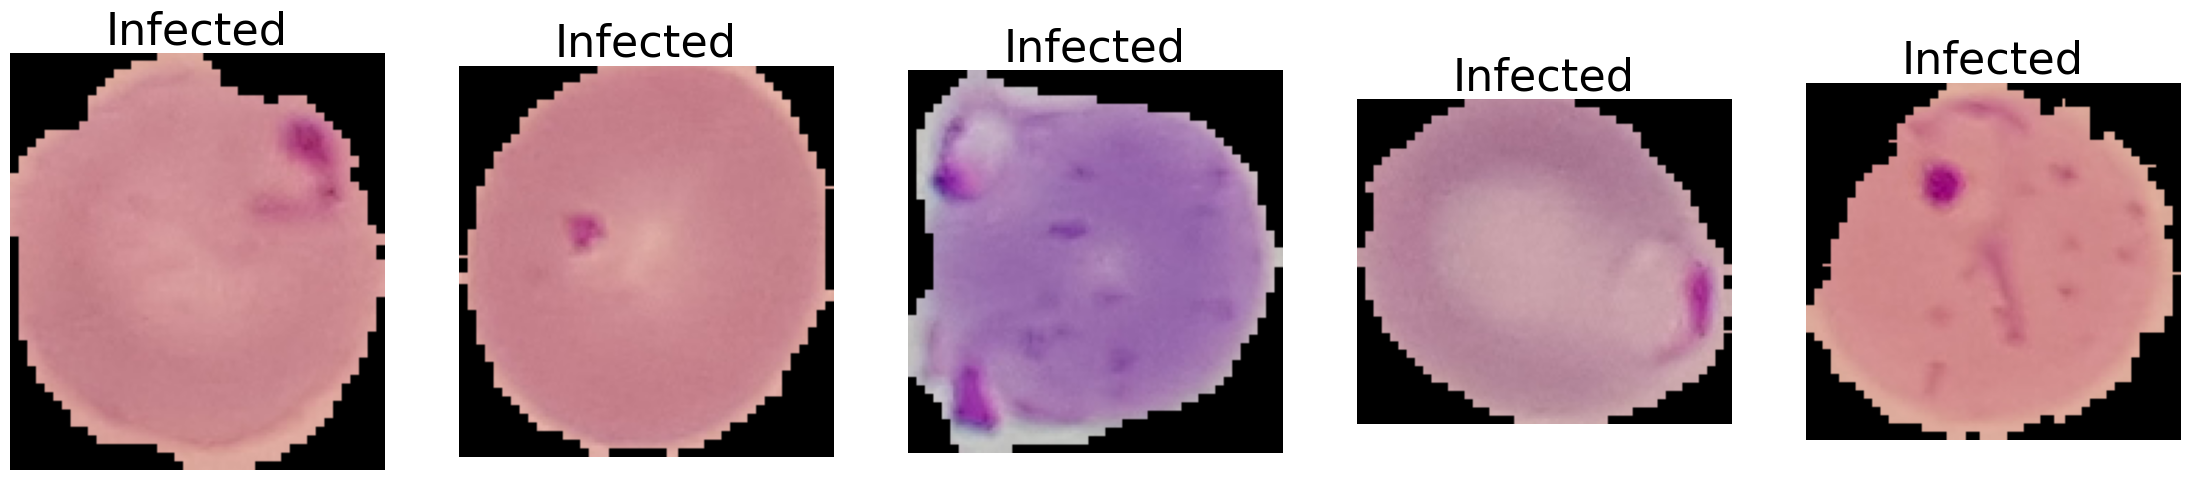

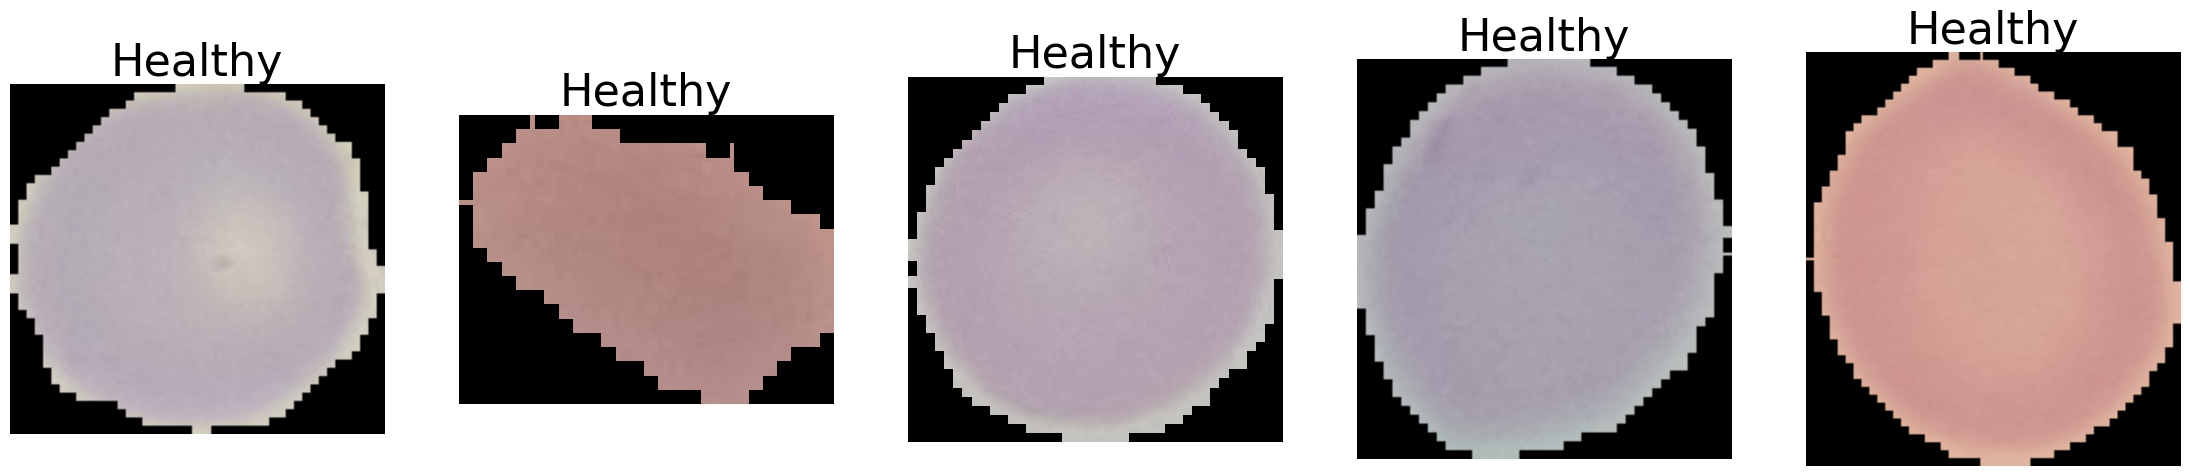

In [39]:
fig =plt.figure(figsize=(28,14))
columns=5
rows=1
for i in range(1, columns*rows +1):
    fig.add_subplot(rows, columns, i)
    plt.imshow(mpimg.imread(infected_trn_samples[i-1]))
    plt.axis('off')
    plt.title('Infected', fontsize=32)
plt.show()


fig =plt.figure(figsize=(28,14))
columns=5
rows=1
for i in range(1, columns*rows +1):
    fig.add_subplot(rows, columns, i)
    plt.imshow(mpimg.imread(healthy_trn_samples[i-1]))
    plt.axis('off')
    plt.title('Healthy', fontsize=32)
plt.show()


# Data Augumentation and resizing images

In [40]:
train_datagen = ImageDataGenerator(rescale=1./255.,
                                   horizontal_flip=True,
                                   vertical_flip=0.4,
                                   rotation_range=30,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   brightness_range=[0.8,1.2],
                                   fill_mode='nearest')
valid_datagen = ImageDataGenerator(rescale=1.0/255.)
test_datagen = ImageDataGenerator(rescale=1.0/255.)

train_generator = train_datagen.flow_from_directory(train_dir,
                                                    batch_size=32,
                                                    target_size=(128,128),
                                                    class_mode='categorical',
                                                    shuffle=True,
                                                    seed=42,
                                                    color_mode='rgb')

valid_generator = valid_datagen.flow_from_directory(valid_dir,
                                                    batch_size=32,
                                                    target_size=(128, 128),
                                                    class_mode='categorical',
                                                    shuffle=True,
                                                    seed=42,
                                                    color_mode='rgb')

class_labels = train_generator.class_indices
class_names = {value:key for (key, value) in class_labels.items()}

Found 26502 images belonging to 2 classes.
Found 5327 images belonging to 2 classes.


In [41]:
class_labels, class_names

({'healthy': 0, 'infected': 1}, {0: 'healthy', 1: 'infected'})

# Unfreezing and Fine-tuning the entire network

In [42]:
# Instantiate VGG19 model with weights from Imagenet without the calssifier at the top
base_model = VGG19(input_shape = (128,128,3),
                   include_top = False, 
                   weights = 'imagenet')
# Freeze the ConvNet to avoid weight updates
for layer in base_model.layers:
    layer.trainable=False
    
x = base_model.output
flat=Flatten()(x)

# Add a classifier -  a fully connected dense layers
class_1 = Dense(4608, activation='relu')(flat)
drop_out = Dropout(0.2)(class_1)
class_2 = Dense(1152, activation='relu')(drop_out)
output = Dense(2, activation='softmax')(class_2)

# Call backs
filepath = 'best_model.h5'
es = EarlyStopping(monitor='val_loss', verbose=1, mode='min', patience=4)
cp = ModelCheckpoint(filepath, monitor='val_loss', verbose=1, save_best_only=True,
                     save_weights_only=False, mode='auto', save_freq='epoch')
lrr = ReduceLROnPlateau(monitor='val_accuracy',patience=3,verbose=1,factor=0.5,min_lr=0.0001)

# Define an optimizer
sgd = SGD(learning_rate=.0001, decay=1e-6, momentum=0.9, nesterov=True)



/Users/shreyasaniya/Downloads/malaria-detection-combined-main/venv/lib/python3.11/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [43]:
# Build the network
base_model = VGG19(include_top=False, input_shape=(128,128,3))
x = base_model.output
x = cbam_block(x)
flat=Flatten()(x)
class_1 = Dense(4608, activation='relu')(flat)
drop_out = Dropout(0.2)(class_1)
class_2 = Dense(1152, activation='relu')(drop_out)
output = Dense(2, activation='softmax')(class_2)
model_03 = Model(base_model.inputs, output)

sgd = SGD(learning_rate=0.0001, momentum=0.9, nesterov=True)
# Compile the model
model_03.compile(optimizer=sgd, loss='categorical_crossentropy', metrics=['accuracy'])

In [44]:
history_03 = model_03.fit(train_generator,
                                    steps_per_epoch=100,
                                    epochs=10,
                                    callbacks = [es, cp, lrr],
                                    validation_data = valid_generator)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.5699 - loss: 0.6836
Epoch 1: val_loss improved from None to 0.33349, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 1309s 13s/step - accuracy: 0.6513 - loss: 0.6162 - val_accuracy: 0.8900 - val_loss: 0.3335 - learning_rate: 1.0000e-04
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.8653 - loss: 0.3267
Epoch 2: val_loss improved from 0.33349 to 0.18708, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 1402s 14s/step - accuracy: 0.8875 - loss: 0.2902 - val_accuracy: 0.9523 - val_loss: 0.1871 - learning_rate: 1.0000e-04
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9135 - loss: 0.2451
Epoch 3: val_loss improved from 0.18708 to 0.14863, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 1355s 14s/step - accuracy: 0.9134 - loss: 0.2450 - val_accuracy: 0.9533 - val_loss: 0.1486 - learning_rate: 1.0000e-04
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9237 - loss: 0.2211
Epoch 4: val_loss improved from 0.14863 to 0.13026, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 1378s 14s/step - accuracy: 0.9312 - loss: 0.2037 - val_accuracy: 0.9595 - val_loss: 0.1303 - learning_rate: 1.0000e-04
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.9360 - loss: 0.1956 
Epoch 5: val_loss improved from 0.13026 to 0.12790, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 1778s 18s/step - accuracy: 0.9300 - loss: 0.2088 - val_accuracy: 0.9600 - val_loss: 0.1279 - learning_rate: 1.0000e-04
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9265 - loss: 0.2129
Epoch 6: val_loss improved from 0.12790 to 0.12136, saving model to best_model.h5



Epoch 6: finished saving model to best_model.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 1292s 13s/step - accuracy: 0.9294 - loss: 0.2100 - val_accuracy: 0.9619 - val_loss: 0.1214 - learning_rate: 1.0000e-04
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9283 - loss: 0.2059
Epoch 7: val_loss improved from 0.12136 to 0.12007, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 1250s 13s/step - accuracy: 0.9287 - loss: 0.1981 - val_accuracy: 0.9619 - val_loss: 0.1201 - learning_rate: 1.0000e-04
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9339 - loss: 0.1948
Epoch 8: val_loss did not improve from 0.12007
100/100 ━━━━━━━━━━━━━━━━━━━━ 1279s 13s/step - accuracy: 0.9378 - loss: 0.1889 - val_accuracy: 0.9617 - val_loss: 0.1237 - learning_rate: 1.0000e-04
Epoch 9/10
 29/100 ━━━━━━━━━━━━━━━━━━━━ 10:18 9s/step - accuracy: 0.9477 - loss: 0.1714

/Users/shreyasaniya/Downloads/malaria-detection-combined-main/venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 9: val_loss did not improve from 0.12007
100/100 ━━━━━━━━━━━━━━━━━━━━ 658s 7s/step - accuracy: 0.9375 - loss: 0.1914 - val_accuracy: 0.9634 - val_loss: 0.1229 - learning_rate: 1.0000e-04
Epoch 10/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9361 - loss: 0.1893
Epoch 10: val_loss did not improve from 0.12007
100/100 ━━━━━━━━━━━━━━━━━━━━ 1299s 13s/step - accuracy: 0.9331 - loss: 0.1958 - val_accuracy: 0.9634 - val_loss: 0.1256 - learning_rate: 1.0000e-04


In [45]:
# save model
if not os.path.isdir('model_weights/'):
    os.mkdir('model_weights/')
model_03.save_weights(filepath='model_weights/vgg_unfrozen.weights.h5', overwrite=True)

## Evaluating the model

In [46]:
# Resize test images similar to the train data
test_generator = test_datagen.flow_from_directory(test_dir,
                                                  batch_size=1,
                                                  target_size=(128, 128),
                                                  class_mode='categorical',
                                                  shuffle=False,
                                                  seed=42,
                                                  color_mode='rgb')

Found 5322 images belonging to 2 classes.


167/167 ━━━━━━━━━━━━━━━━━━━━ 422s 3s/step - accuracy: 0.9634 - loss: 0.1256
5322/5322 ━━━━━━━━━━━━━━━━━━━━ 537s 101ms/step - accuracy: 0.9519 - loss: 0.1517
Validation loss     :0.13
Validation accuracy :0.96
Test loss           :0.15
Test accuracy       :0.95
5322/5322 ━━━━━━━━━━━━━━━━━━━━ 546s 103ms/step
              precision    recall  f1-score   support

     healthy       0.95      0.96      0.95      2643
    infected       0.96      0.95      0.95      2679

    accuracy                           0.95      5322
   macro avg       0.95      0.95      0.95      5322
weighted avg       0.95      0.95      0.95      5322



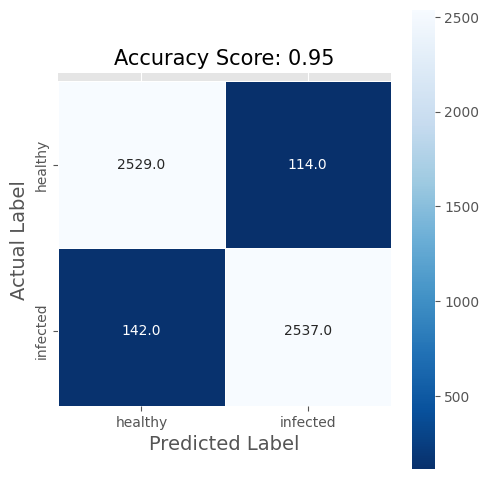

In [47]:
# Load the saved model
model_03.load_weights('model_weights/vgg_unfrozen.weights.h5')

# Evaluate the model on the hold out validation and test datasets

vgg_val_eval_03 = model_03.evaluate(valid_generator)
vgg_test_eval_03 = model_03.evaluate(test_generator)

print('Validation loss     :{0:.2f}'.format(vgg_val_eval_03[0]))
print('Validation accuracy :{0:.2f}'.format(vgg_val_eval_03[1]))
print('Test loss           :{0:.2f}'.format(vgg_test_eval_03[0]))
print('Test accuracy       :{0:.2f}'.format(vgg_test_eval_03[1]))


filenames = test_generator.filenames
nb_samples = len(filenames)
vgg_predictions_03 = model_03.predict(test_generator,
                                                steps = nb_samples,
                                                verbose=1)
vgg_pred_labels_03 = np.argmax(vgg_predictions_03, axis=1)


# Classification Report
print(classification_report(test_generator.classes, vgg_pred_labels_03, 
                            target_names=['healthy', 'infected']))
vgg_conf_mat_03 = pd.DataFrame(confusion_matrix(test_generator.classes, vgg_pred_labels_03), 
                        index=['healthy', 'infected'], 
                        columns=['healthy', 'infected'])


fig, ax = plt.subplots(figsize=(5,5))

sns.heatmap(vgg_conf_mat_03, annot=True, fmt=".1f", linewidths=0.5, square=True, cmap='Blues_r')
ax.set_ylabel("Actual Label", fontsize=14)
ax.set_xlabel("Predicted Label", fontsize=14)
all_sample_title="Accuracy Score: {0:.2f}".format(vgg_test_eval_03[1])
ax.set_title(all_sample_title, size=15)
ax.set_ylim(len(vgg_conf_mat_03)-0.05, -0.05)
plt.tight_layout()

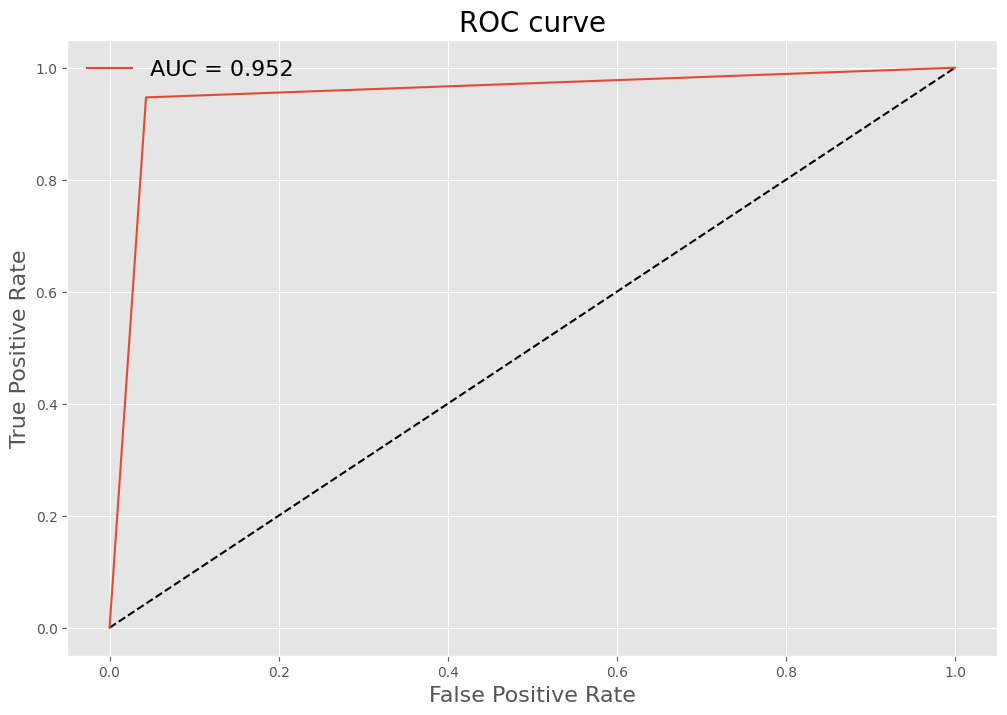

In [48]:
# AUC Curve
false_positive_rate, true_positive_rate, threshold = roc_curve(test_generator.classes, vgg_pred_labels_03)
area_under_curve = auc(false_positive_rate, true_positive_rate)

# Plot AUC Curve
fig, ax = plt.subplots(figsize=(12,8))
ax.plot([0,1], [0,1], 'k--')
ax.plot(false_positive_rate, true_positive_rate, label='AUC = {:.3f}'.format(area_under_curve))
ax.set_xlabel('False Positive Rate', fontsize=16)
ax.set_ylabel('True Positive Rate', fontsize=16)
ax.set_title("ROC curve", fontsize=20)
ax.legend(frameon=False, loc='best', ncol=1, fontsize=16)

# Prediction Results for 10 randomly selected images

In [49]:
test_images = [img for img in random.sample(infected_test_fpaths, 5)]
test_images.extend([img for img in random.sample(healthy_test_fpaths, 5)])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


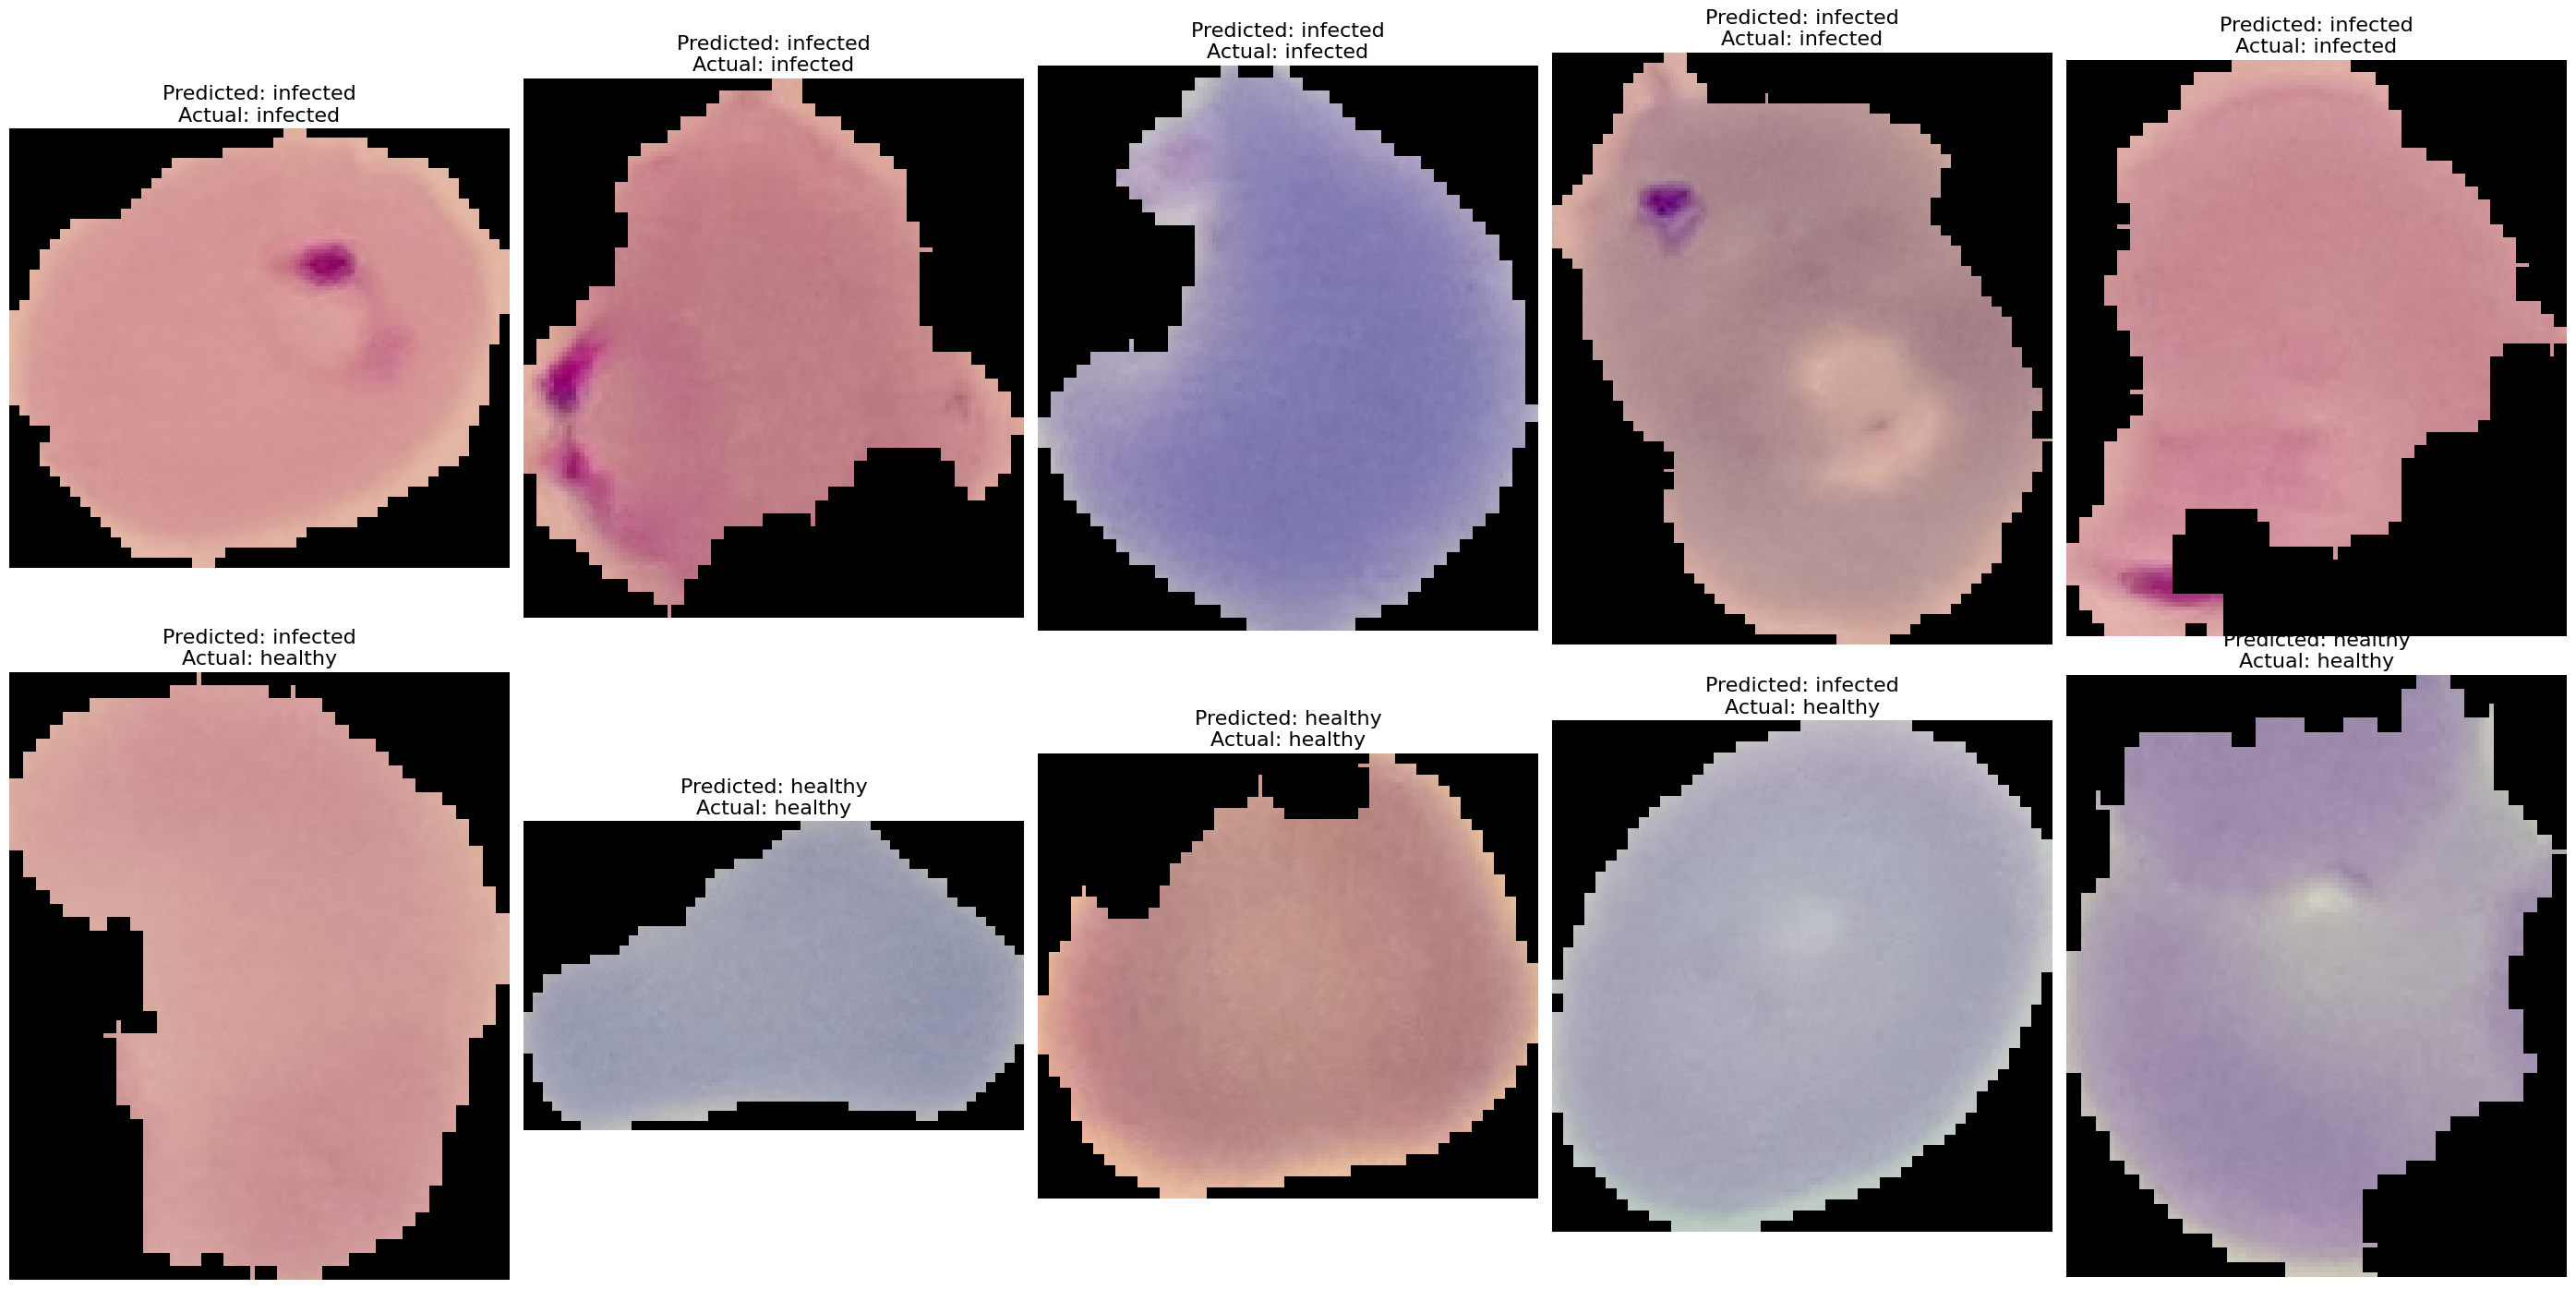

In [50]:
from tensorflow.keras.preprocessing import image
true_labels = []
predicted_labels = [] 
fig = plt.figure(figsize=(28,14))
columns=5
rows=2
for i in range(1, columns*rows +1):
    fig.add_subplot(rows, columns, i)
    true_label = os.path.basename(os.path.dirname(test_images[i-1]))
    img = mpimg.imread(test_images[i-1])
    plt.imshow(img)
    plt.axis('off')
    img_for_model = image.load_img(test_images[i-1], target_size=(128,128))
    img_for_model = image.img_to_array(img_for_model)
    img_for_model = np.expand_dims(img_for_model, axis=0)
    prediction = model_03.predict(img_for_model)
    predicted_label = np.argmax(prediction)
    plt.title(f"Predicted: {class_names[predicted_label]}\nActual: {true_label}", fontsize=16)
plt.tight_layout()
plt.show()

# Interpretable the classifier with LIME for Image Classification

In [51]:
!pip3 install lime

  Using cached lime-0.2.0.1-py3-none-any.whl


In [52]:
%load_ext autoreload
%autoreload 2
import os,sys
import lime
from lime import lime_image
from skimage.segmentation import mark_boundaries

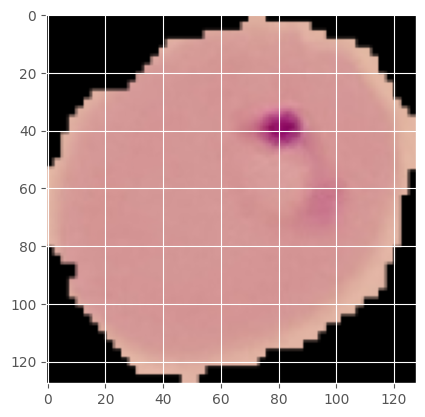

In [53]:
test_image = skimage.io.imread(test_images[0])
test_image = skimage.transform.resize(test_image, (128,128))
import matplotlib.pyplot as plt
plt.imshow(test_image)
plt.grid(True)       
plt.axis('on')       
plt.show()


# img = image.load_img(test_images[i-1], target_size=(128,128))
# img = image.img_to_array(img)
# img = np.expand_dims(img, axis = 0)
# prediction = model_03.predict(img)
# prediction

In [54]:
explainer = lime_image.LimeImageExplainer()

In [55]:
%%time
# Hide color is the color for a superpixel turned OFF. Alternatively, if it is NONE, the superpixel will be replaced by the average of its pixels
explanation = explainer.explain_instance(test_image, model_03.predict, top_labels=1, hide_color=0)

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 843ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 800ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 778ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 778ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 851ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 772ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 781ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 792ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 670ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 791ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 788ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 844ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 847ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 852ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 740ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 737ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 805ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 736ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 748ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 720ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 718ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 715ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 727ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 711

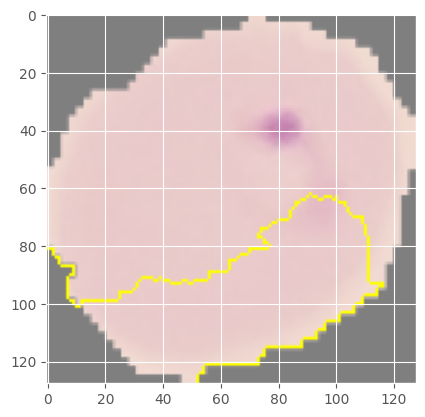

In [56]:
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=30, hide_rest=False)
plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tensorflow as tf
import cv2
import os
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image

In [60]:
print([var for var in dir() if 'model' in var.lower()])

['Model', 'ModelCheckpoint', 'base_model', 'img_for_model', 'load_model', 'model_03']


In [61]:
model = model_03

In [67]:
def make_gradcam_heatmap(img_array, model):
    last_conv_layer = None
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            if layer.output.shape[-1] >= 256:  # ← pick a deeper layer
                last_conv_layer = layer.name
                break
    print(f"Using layer: {last_conv_layer}")

    grad_model = Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

In [68]:
def overlay_gradcam(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_colored = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_colored, cv2.COLORMAP_JET)
    superimposed = cv2.addWeighted(img, 1 - alpha, heatmap_colored, alpha, 0)
    return cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB)

In [69]:
parasitized_dir = '/Users/shreyasaniya/Downloads/malaria-detection-combined-main/cell_images/Parasitized'
uninfected_dir  = '/Users/shreyasaniya/Downloads/malaria-detection-combined-main/cell_images/Uninfected'

sample_infected   = [os.path.join(parasitized_dir, f) for f in os.listdir(parasitized_dir) if f.endswith('.png')][:3]
sample_uninfected = [os.path.join(uninfected_dir,  f) for f in os.listdir(uninfected_dir)  if f.endswith('.png')][:3]
samples = sample_infected + sample_uninfected
labels  = ['Infected']*3 + ['Uninfected']*3

Using layer: block5_conv4
Using layer: block5_conv4
Using layer: block5_conv4
Using layer: block5_conv4
Using layer: block5_conv4
Using layer: block5_conv4


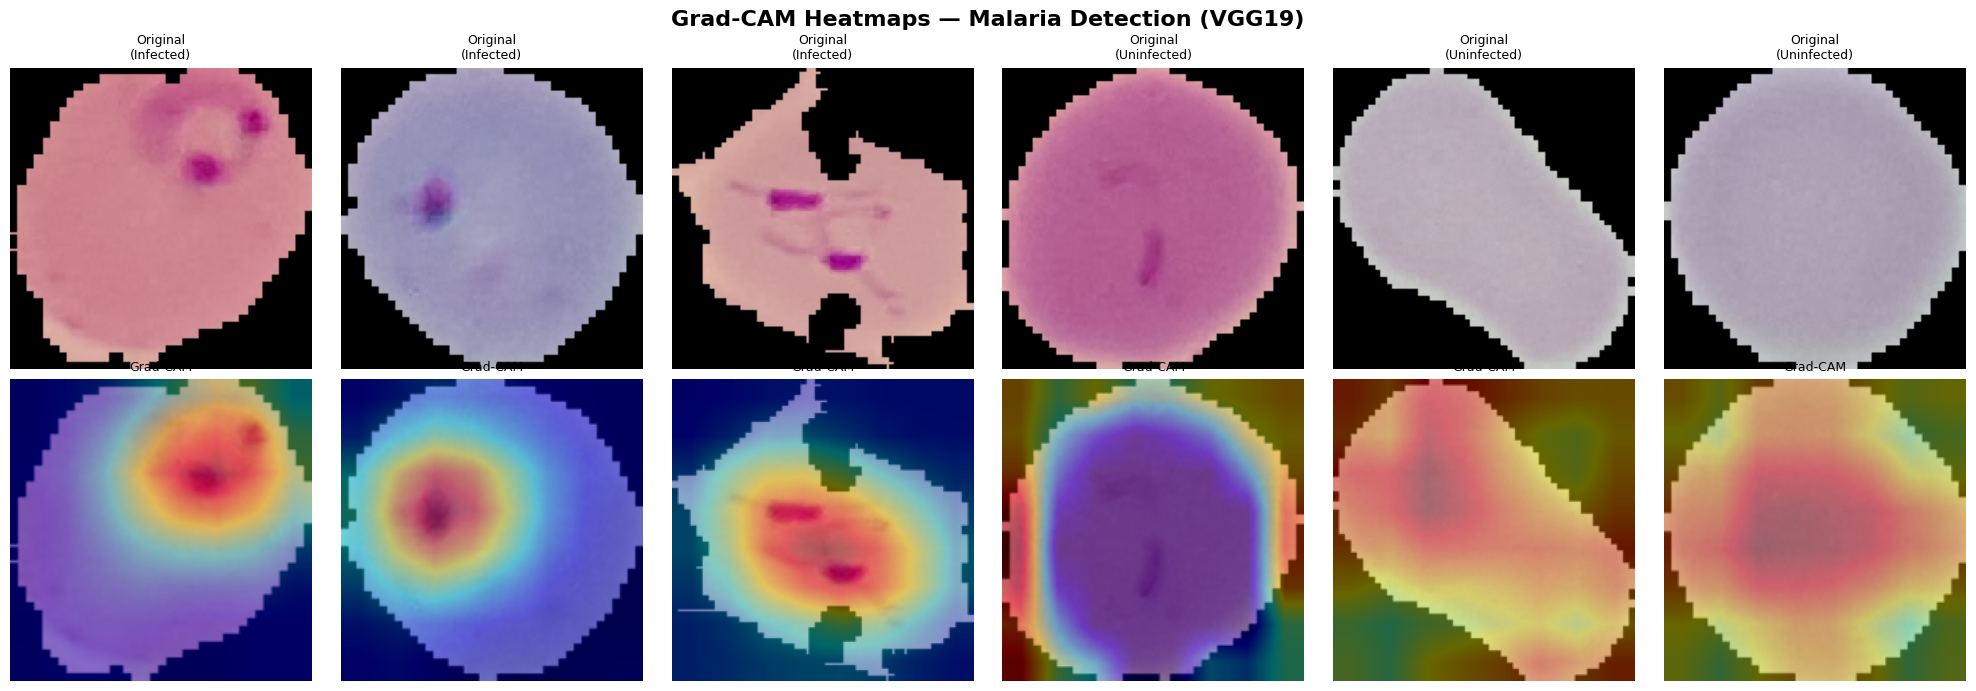

Saved as gradcam_results.png


In [70]:
fig, axes = plt.subplots(2, 6, figsize=(20, 7))
fig.suptitle('Grad-CAM Heatmaps — Malaria Detection (VGG19)', fontsize=16, fontweight='bold')

for i, (img_path, label) in enumerate(zip(samples, labels)):
    img = image.load_img(img_path, target_size=(128, 128))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array / 255.0, axis=0)

    heatmap = make_gradcam_heatmap(img_array, model)
    overlay = overlay_gradcam(img_path, heatmap)

    # Original
    axes[0, i].imshow(img)
    axes[0, i].set_title(f'Original\n({label})', fontsize=9)
    axes[0, i].axis('off')

    # Grad-CAM
    axes[1, i].imshow(overlay)
    axes[1, i].set_title('Grad-CAM', fontsize=9)
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('gradcam_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as gradcam_results.png")

**Refrences:**
    1. Deep Learning with Python: François Chollet
    
    2. Malaria Detection - Deep Learning Healthcare Case-Study https://github.com/dipanjanS/data_science_for_all/blob/master/os_malaria_detection/Malaria%20Detection%20-%20Deep%20Learning%20Healthcare%20Case-Study.ipynb
    
    3. LIME Tutorial https://github.com/marcotcr/lime/blob/master/doc/notebooks/Tutorial%20-%20Image%20Classification%20Keras.ipynb
     

In [74]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    '/Users/shreyasaniya/Downloads/malaria-detection-combined-main/healthy_and_infected/test',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# Manual evaluation
all_preds = []
all_labels = []

for i in range(len(test_generator)):
    x_batch, y_batch = test_generator[i]
    preds = model_03.predict(x_batch, verbose=0)
    all_preds.extend((preds[:, 0] > 0.5).astype(int).flatten())
    all_labels.extend(y_batch.astype(int).flatten())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

accuracy = np.mean(all_preds == all_labels)
print(f"\n Model Accuracy: {accuracy * 100:.2f}%")
print(f" Total images tested: {len(all_labels)}")

Found 5322 images belonging to 2 classes.

 Model Accuracy: 4.81%
 Total images tested: 5322


In [75]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img

# Load test images manually
test_dir = '/Users/shreyasaniya/Downloads/malaria-detection-combined-main/healthy_and_infected/test'

# TTA augmentations
tta_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=20,
    zoom_range=0.1
)
normal_datagen = ImageDataGenerator(rescale=1./255)

# Get all test images and labels
test_generator = normal_datagen.flow_from_directory(
    test_dir,
    target_size=(128, 128),
    batch_size=1,
    class_mode='binary',
    shuffle=False
)

TTA_STEPS = 10  # number of augmented versions per image
all_preds = []
all_labels = []

print("Running TTA... this will take a few minutes")

for i in range(len(test_generator)):
    x_batch, y_batch = test_generator[i]
    img = x_batch[0]
    
    # Run TTA
    tta_preds = []
    for _ in range(TTA_STEPS):
        augmented = tta_datagen.random_transform(img)
        augmented = np.expand_dims(augmented, axis=0)
        pred = model_03.predict(augmented, verbose=0)[0][0]
        tta_preds.append(pred)
    
    # Average predictions
    avg_pred = np.mean(tta_preds)
    all_preds.append(1 if avg_pred > 0.5 else 0)
    all_labels.append(int(y_batch[0]))

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

tta_accuracy = np.mean(all_preds == all_labels)
print(f"\nOriginal Accuracy:  95.00%")
print(f"TTA Accuracy:       {tta_accuracy * 100:.2f}%")
print(f"Improvement:        +{(tta_accuracy - 0.95) * 100:.2f}%")

Found 5322 images belonging to 2 classes.
Running TTA... this will take a few minutes

Original Accuracy:  95.00%
TTA Accuracy:       5.19%
Improvement:        +-89.81%


In [77]:
model_03.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 128, 128,  │      1,792 │ input_layer_1[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 128, 128,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 64, 64,    │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 64, 64,    │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 64, 64,    │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 32, 32,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 32, 32,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 32, 32,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 32, 32,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv4        │ (None, 32, 32,    │    590,080 │ block3_conv3[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 16, 16,    │          0 │ block3_conv4[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 16, 16,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 16, 16,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 16, 16,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv4        │ (None, 16, 16,    │  2,359,808 │ block4_conv3[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 8, 8, 512) │          0 │ block4_conv4[0][

 Total params: 126,311,628 (481.84 MB)

 Trainable params: 63,155,813 (240.92 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 63,155,815 (240.92 MB)

In [79]:
print("Total layers:", len(model_03.layers))
for i, layer in enumerate(model_03.layers):
    print(i, layer.name, "— trainable:", layer.trainable)
    

Total layers: 39
0 input_layer_1 — trainable: True
1 block1_conv1 — trainable: True
2 block1_conv2 — trainable: True
3 block1_pool — trainable: True
4 block2_conv1 — trainable: True
5 block2_conv2 — trainable: True
6 block2_pool — trainable: True
7 block3_conv1 — trainable: True
8 block3_conv2 — trainable: True
9 block3_conv3 — trainable: True
10 block3_conv4 — trainable: True
11 block3_pool — trainable: True
12 block4_conv1 — trainable: True
13 block4_conv2 — trainable: True
14 block4_conv3 — trainable: True
15 block4_conv4 — trainable: True
16 block4_pool — trainable: True
17 block5_conv1 — trainable: True
18 block5_conv2 — trainable: True
19 block5_conv3 — trainable: True
20 block5_conv4 — trainable: True
21 block5_pool — trainable: True
22 global_average_pooling2d — trainable: True
23 global_max_pooling2d — trainable: True
24 dense_3 — trainable: True
25 dense_4 — trainable: True
26 add — trainable: True
27 reshape — trainable: True
28 multiply — trainable: True
29 lambda — trainab

In [81]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, GlobalAveragePooling2D
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Freeze all VGG19 base layers
for layer in model_03.layers[:22]:
    layer.trainable = False

# Get output from CBAM (multiply_1 layer)
cbam_output = model_03.get_layer('multiply_1').output

# New cleaner top layers
x = Flatten()(cbam_output)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

new_model = Model(inputs=model_03.input, outputs=output)

new_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.1
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    '/Users/shreyasaniya/Downloads/malaria-detection-combined-main/healthy_and_infected/train',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)
val_gen = val_datagen.flow_from_directory(
    '/Users/shreyasaniya/Downloads/malaria-detection-combined-main/healthy_and_infected/valid',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)

callbacks = [
    ModelCheckpoint('best_model_v2.h5', save_best_only=True, monitor='val_accuracy', verbose=1),
    EarlyStopping(patience=5, monitor='val_accuracy', restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history = new_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks
)

print("\nTraining complete!")
print(f"Best val accuracy: {max(history.history['val_accuracy']) * 100:.2f}%")

Found 26502 images belonging to 2 classes.
Found 5327 images belonging to 2 classes.
Epoch 1/10
829/829 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9452 - loss: 0.1610
Epoch 1: val_accuracy improved from None to 0.96677, saving model to best_model_v2.h5



Epoch 1: finished saving model to best_model_v2.h5
829/829 ━━━━━━━━━━━━━━━━━━━━ 2360s 3s/step - accuracy: 0.9555 - loss: 0.1384 - val_accuracy: 0.9668 - val_loss: 0.1023 - learning_rate: 1.0000e-04
Epoch 2/10
829/829 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9581 - loss: 0.1248
Epoch 2: val_accuracy improved from 0.96677 to 0.96696, saving model to best_model_v2.h5



Epoch 2: finished saving model to best_model_v2.h5
829/829 ━━━━━━━━━━━━━━━━━━━━ 2325s 3s/step - accuracy: 0.9587 - loss: 0.1249 - val_accuracy: 0.9670 - val_loss: 0.1006 - learning_rate: 1.0000e-04
Epoch 3/10
829/829 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9613 - loss: 0.1180
Epoch 3: val_accuracy improved from 0.96696 to 0.96771, saving model to best_model_v2.h5



Epoch 3: finished saving model to best_model_v2.h5
829/829 ━━━━━━━━━━━━━━━━━━━━ 2356s 3s/step - accuracy: 0.9596 - loss: 0.1206 - val_accuracy: 0.9677 - val_loss: 0.0956 - learning_rate: 1.0000e-04
Epoch 4/10
829/829 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9627 - loss: 0.1146
Epoch 4: val_accuracy did not improve from 0.96771
829/829 ━━━━━━━━━━━━━━━━━━━━ 2205s 3s/step - accuracy: 0.9609 - loss: 0.1171 - val_accuracy: 0.9673 - val_loss: 0.0956 - learning_rate: 1.0000e-04
Epoch 5/10
829/829 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9628 - loss: 0.1066
Epoch 5: val_accuracy improved from 0.96771 to 0.96865, saving model to best_model_v2.h5



Epoch 5: finished saving model to best_model_v2.h5
829/829 ━━━━━━━━━━━━━━━━━━━━ 2293s 3s/step - accuracy: 0.9616 - loss: 0.1130 - val_accuracy: 0.9687 - val_loss: 0.0932 - learning_rate: 1.0000e-04
Epoch 6/10
829/829 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9612 - loss: 0.1107
Epoch 6: val_accuracy improved from 0.96865 to 0.96884, saving model to best_model_v2.h5



Epoch 6: finished saving model to best_model_v2.h5
829/829 ━━━━━━━━━━━━━━━━━━━━ 2275s 3s/step - accuracy: 0.9623 - loss: 0.1108 - val_accuracy: 0.9688 - val_loss: 0.0923 - learning_rate: 1.0000e-04
Epoch 7/10
829/829 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9617 - loss: 0.1111
Epoch 7: val_accuracy did not improve from 0.96884
829/829 ━━━━━━━━━━━━━━━━━━━━ 2190s 3s/step - accuracy: 0.9625 - loss: 0.1095 - val_accuracy: 0.9677 - val_loss: 0.0928 - learning_rate: 1.0000e-04
Epoch 8/10
829/829 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9642 - loss: 0.1042
Epoch 8: val_accuracy did not improve from 0.96884
829/829 ━━━━━━━━━━━━━━━━━━━━ 2317s 3s/step - accuracy: 0.9616 - loss: 0.1079 - val_accuracy: 0.9664 - val_loss: 0.0949 - learning_rate: 1.0000e-04
Epoch 9/10
829/829 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9607 - loss: 0.1116
Epoch 9: val_accuracy did not improve from 0.96884

Epoch 9: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
829/829 ━━━━━━━━━━━━━━


Epoch 10: finished saving model to best_model_v2.h5
829/829 ━━━━━━━━━━━━━━━━━━━━ 2637s 3s/step - accuracy: 0.9630 - loss: 0.1041 - val_accuracy: 0.9692 - val_loss: 0.0882 - learning_rate: 5.0000e-05
Restoring model weights from the end of the best epoch: 10.

Training complete!
Best val accuracy: 96.92%


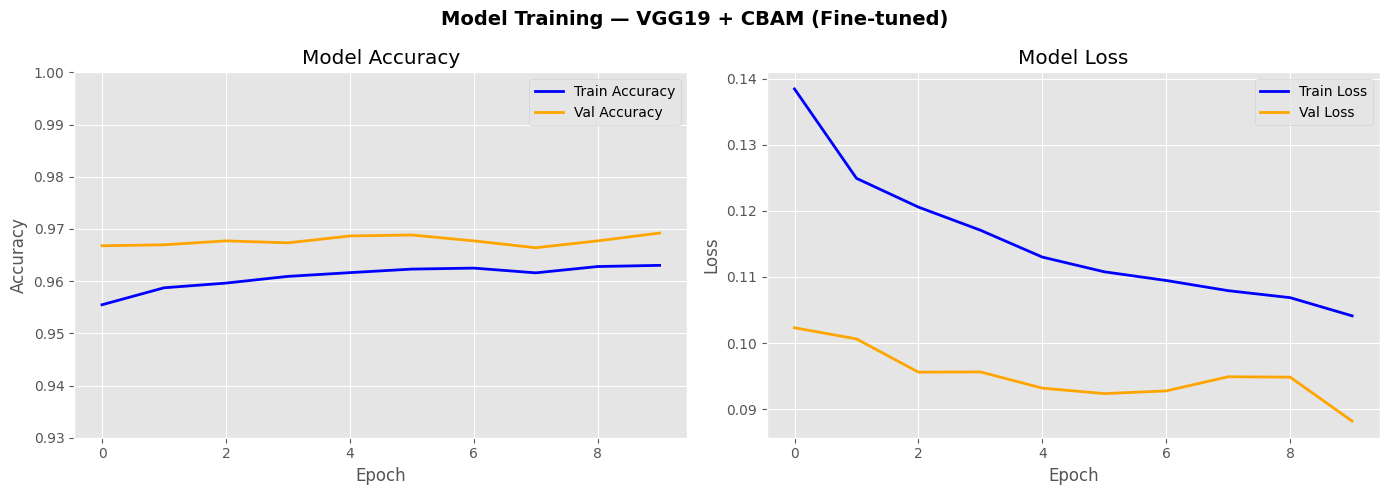

Saved as training_graphs.png


In [82]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Training — VGG19 + CBAM (Fine-tuned)', fontsize=14, fontweight='bold')

# Accuracy graph
axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', color='orange', linewidth=2)
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)
axes[0].set_ylim([0.93, 1.0])

# Loss graph
axes[1].plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss', color='orange', linewidth=2)
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_graphs.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as training_graphs.png")

167/167 ━━━━━━━━━━━━━━━━━━━━ 395s 2s/step - accuracy: 0.9692 - loss: 0.0882
5322/5322 ━━━━━━━━━━━━━━━━━━━━ 483s 91ms/step - accuracy: 0.9570 - loss: 0.1132
Validation loss     :0.09
Validation accuracy :0.97
Test loss           :0.11
Test accuracy       :0.96
5322/5322 ━━━━━━━━━━━━━━━━━━━━ 466s 87ms/step
              precision    recall  f1-score   support

     healthy       0.50      1.00      0.66      2643
    infected       0.00      0.00      0.00      2679

    accuracy                           0.50      5322
   macro avg       0.25      0.50      0.33      5322
weighted avg       0.25      0.50      0.33      5322



/Users/shreyasaniya/Downloads/malaria-detection-combined-main/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/shreyasaniya/Downloads/malaria-detection-combined-main/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/shreyasaniya/Downloads/malaria-detection-combined-main/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Us

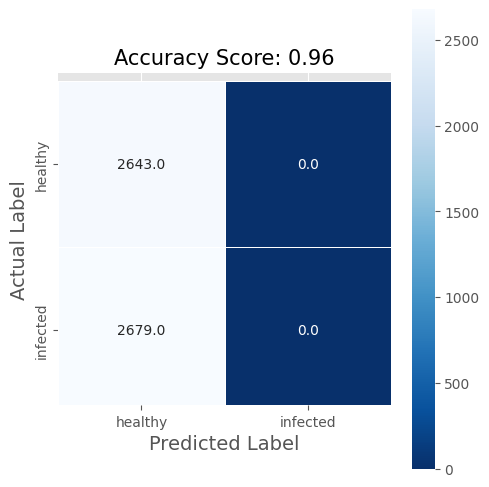

In [83]:
# Evaluate the new fine-tuned model
vgg_val_eval_03 = new_model.evaluate(val_gen)
vgg_test_eval_03 = new_model.evaluate(test_generator)

print('Validation loss     :{0:.2f}'.format(vgg_val_eval_03[0]))
print('Validation accuracy :{0:.2f}'.format(vgg_val_eval_03[1]))
print('Test loss           :{0:.2f}'.format(vgg_test_eval_03[0]))
print('Test accuracy       :{0:.2f}'.format(vgg_test_eval_03[1]))

filenames = test_generator.filenames
nb_samples = len(filenames)

vgg_predictions_03 = new_model.predict(test_generator, steps=nb_samples, verbose=1)
vgg_pred_labels_03 = np.argmax(vgg_predictions_03, axis=1)

# Classification Report
print(classification_report(test_generator.classes, vgg_pred_labels_03,
target_names=['healthy', 'infected']))

vgg_conf_mat_03 = pd.DataFrame(confusion_matrix(test_generator.classes, vgg_pred_labels_03),
index=['healthy', 'infected'],
columns=['healthy', 'infected'])

fig, ax = plt.subplots(figsize=(5,5))
sns.heatmap(vgg_conf_mat_03, annot=True, fmt=".1f", linewidths=0.5, square=True, cmap='Blues_r')
ax.set_ylabel("Actual Label", fontsize=14)
ax.set_xlabel("Predicted Label", fontsize=14)
all_sample_title = "Accuracy Score: {0:.2f}".format(vgg_test_eval_03[1])
ax.set_title(all_sample_title, size=15)
ax.set_ylim(len(vgg_conf_mat_03)-0.05, -0.05)
plt.tight_layout()
plt.savefig('confusion_matrix_v2.png', dpi=150, bbox_inches='tight')
plt.show()

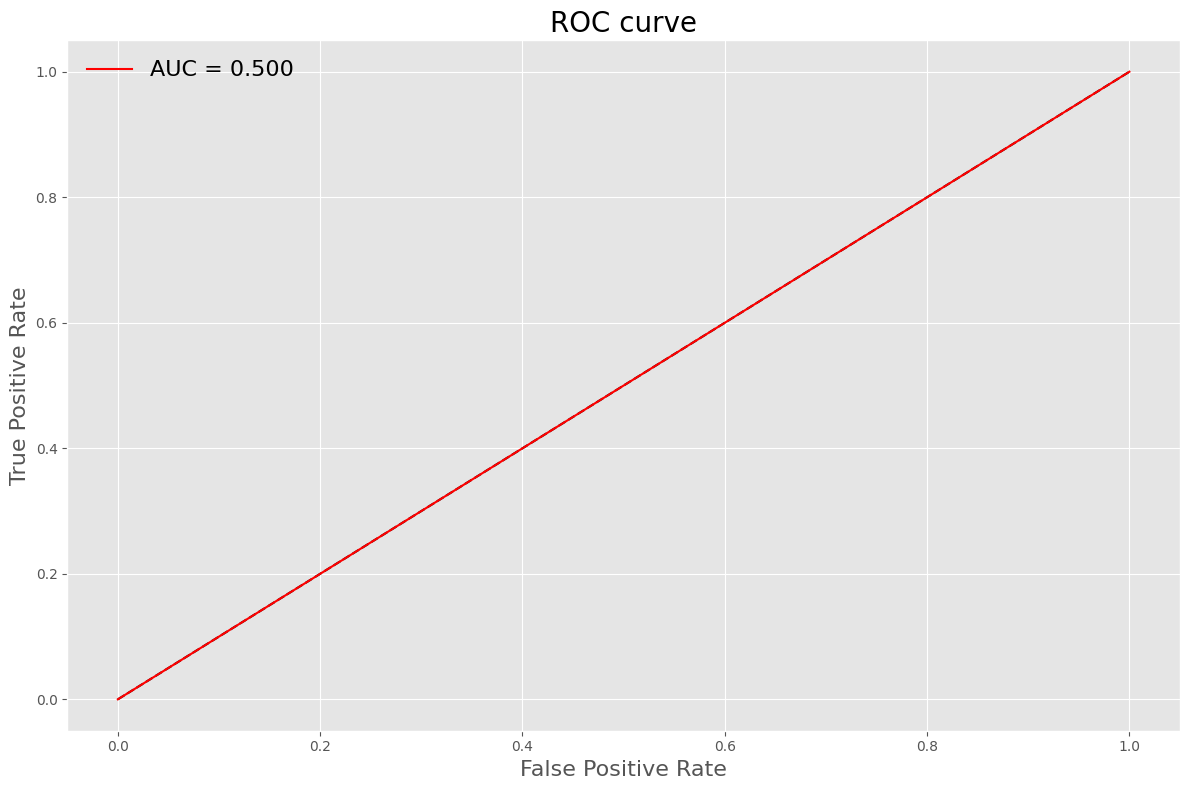

In [84]:
# AUC Curve
false_positive_rate, true_positive_rate, threshold = roc_curve(test_generator.classes, vgg_pred_labels_03)
area_under_curve = auc(false_positive_rate, true_positive_rate)

# Plot AUC Curve
fig, ax = plt.subplots(figsize=(12,8))
ax.plot([0,1], [0,1], 'k--')
ax.plot(false_positive_rate, true_positive_rate, color='red', label='AUC = {:.3f}'.format(area_under_curve))
ax.set_xlabel('False Positive Rate', fontsize=16)
ax.set_ylabel('True Positive Rate', fontsize=16)
ax.set_title("ROC curve", fontsize=20)
ax.legend(frameon=False, loc='best', ncol=1, fontsize=16)
plt.tight_layout()
plt.savefig('roc_curve_v2.png', dpi=150, bbox_inches='tight')
plt.show()